# Random Forest Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

from preprocessing_utils_fixed import (
    load_and_prepare_data_fixed,
    create_preprocessing_pipeline,
    evaluate_with_cross_validation,
    print_evaluation_metrics_fixed
)

## Load and Prepare Data

In [2]:
print("\n" + "="*80)
print("RANDOM FOREST MODEL")
print("="*80)

X_train, X_test, y_train, y_test, feature_names = \
    load_and_prepare_data_fixed(
        test_size=0.3, 
        random_state=42, 
        exclude_diagnostic_features=True  
    )

print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of features: {len(feature_names)}")


RANDOM FOREST MODEL
FIXED DATA PREPROCESSING (NO DATA LEAKAGE)

[1] Loading dataset from: Dataset/diana_dataset_imputed.csv
    Dataset shape: (1376, 20)

[2] Creating binary target variable
    Class 0 (Non-Diabetic): 1170 (85.03%)
    Class 1 (Diabetic): 206 (14.97%)

[3] EXCLUDING HbA1c and FBS (diagnostic criteria - cause data leakage)
    Using 11 features (no diagnostic markers)
     1. age
     2. bmi
     3. hdl
     4. triglycerides
     5. total_cholesterol
     6. systolic
     7. diastolic
     8. ldl
     9. smoking_status
    10. physical_activity
    11. alcohol_use

[4] Splitting data BEFORE preprocessing (prevents leakage)
    Training set: 963 samples
    Testing set: 413 samples
    Training - Diabetic: 144 (14.95%)
    Testing - Diabetic: 62 (15.01%)

[5] Returning RAW data (preprocessing will be done in Pipeline)
    - This ensures scaler and encoders are fit ONLY on training data
    - Prevents test set information from leaking into training


Training samples: 9

## Correlation Matrix Analysis

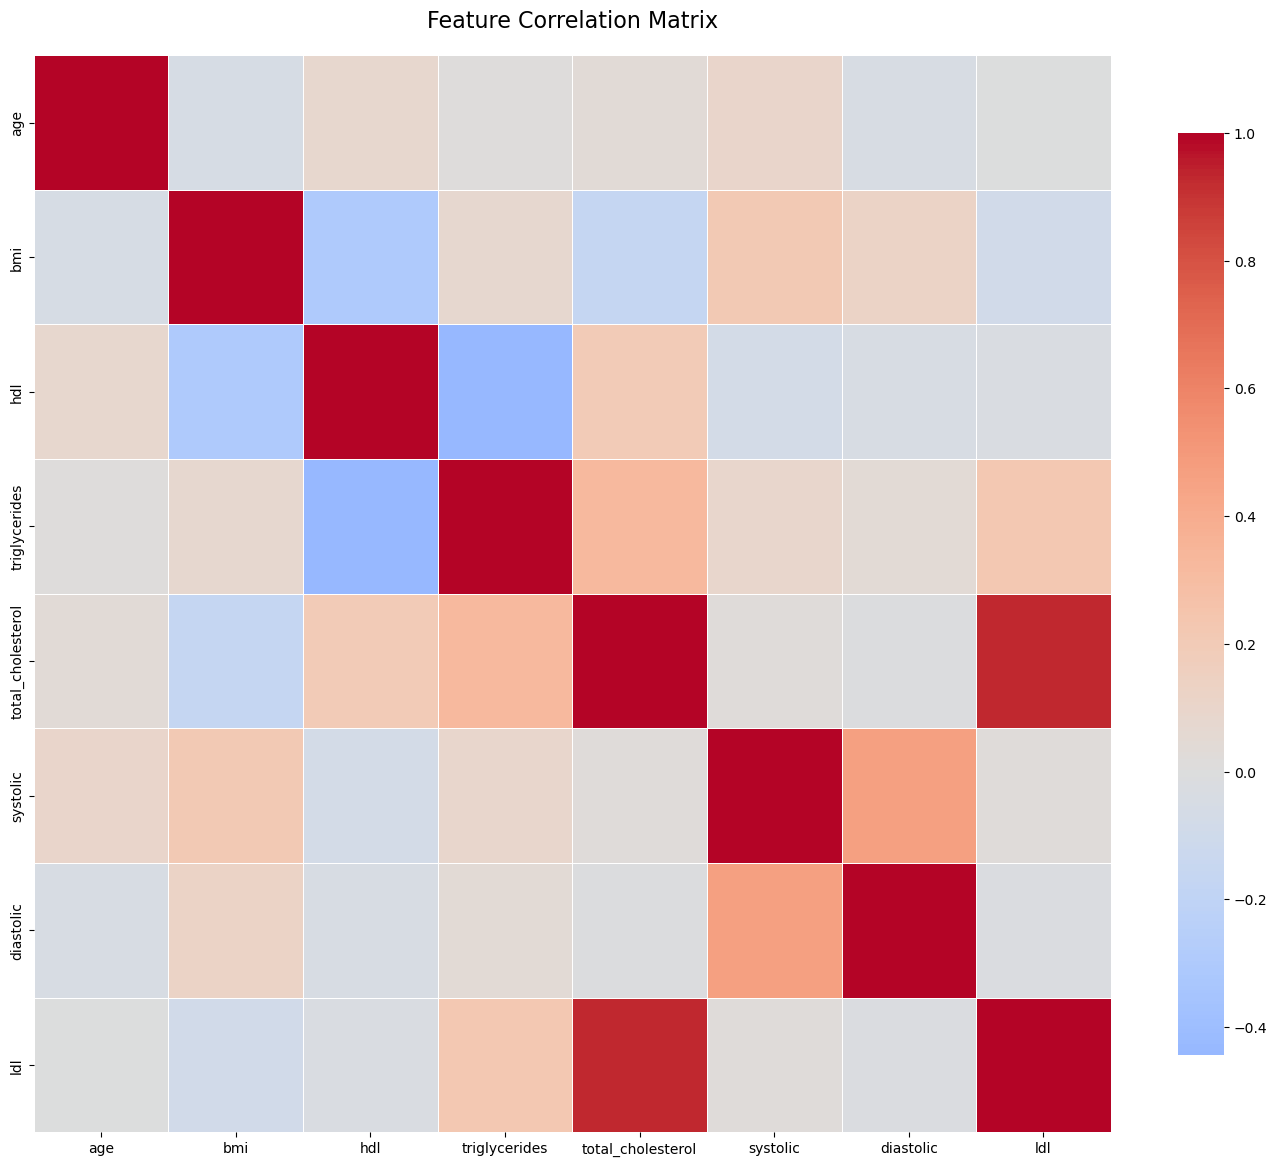


Highly Correlated Feature Pairs (|correlation| > 0.7):
total_cholesterol              <-> ldl                           :  0.932


In [3]:
# Select only numerical features for correlation matrix
numerical_features = X_train.select_dtypes(include=[np.number])

# Calculate correlation matrix
correlation_matrix = numerical_features.corr()

# Create figure
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Show highly correlated features
print("\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
print("="*60)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"{correlation_matrix.columns[i]:30s} <-> {correlation_matrix.columns[j]:30s}: {correlation_matrix.iloc[i, j]:6.3f}")

## Create Preprocessing Pipeline and Model

In [4]:
preprocessor = create_preprocessing_pipeline(X_train, feature_names)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=50, 
        max_depth=5,  
        min_samples_split=20,  
        min_samples_leaf=10, 
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print("Model pipeline created successfully!")


[PIPELINE SETUP]
  Categorical features (3): ['smoking_status', 'physical_activity', 'alcohol_use']
  Numerical features (8): ['age', 'bmi', 'hdl', 'triglycerides', 'total_cholesterol', 'systolic', 'diastolic', 'ldl']
Model pipeline created successfully!


## Cross-Validation

In [5]:
print("\n" + "="*80)
print("CROSS-VALIDATION (Checks for overfitting)")
print("="*80)

cv_results = evaluate_with_cross_validation(model, X_train, y_train, cv=5)


CROSS-VALIDATION (Checks for overfitting)

[CROSS-VALIDATION] Using 5-Fold Stratified CV
  Accuracy    : 0.7456 (+/- 0.0335)
  Precision   : 0.3217 (+/- 0.0363)
  Recall      : 0.6111 (+/- 0.0457)
  F1          : 0.4198 (+/- 0.0336)
  Roc_auc     : 0.7646 (+/- 0.0351)


## Train Model

In [6]:
print("\n" + "="*80)
print("TRAINING ON FULL TRAINING SET")
print("="*80)
print(f"\n[1] Training model on {len(X_train)} samples")

model.fit(X_train, y_train)
print("    Training complete!")


TRAINING ON FULL TRAINING SET

[1] Training model on 963 samples
    Training complete!


## Feature Importance


[2] Extracting feature importance

    Feature Importance Ranking:
    num__bmi                      : 0.2830 |==============
    num__total_cholesterol        : 0.1364 |======
    num__systolic                 : 0.1257 |======
    num__hdl                      : 0.1237 |======
    num__ldl                      : 0.1117 |=====
    num__triglycerides            : 0.1075 |=====
    num__diastolic                : 0.0349 |=
    num__age                      : 0.0305 |=
    cat__smoking_status_Never     : 0.0157 |
    cat__physical_activity_Unknown: 0.0086 |
    cat__smoking_status_Former    : 0.0077 |
    cat__physical_activity_Moderate: 0.0056 |
    cat__physical_activity_Sedentary: 0.0037 |
    cat__alcohol_use_Moderate     : 0.0029 |
    cat__alcohol_use_Light        : 0.0024 |


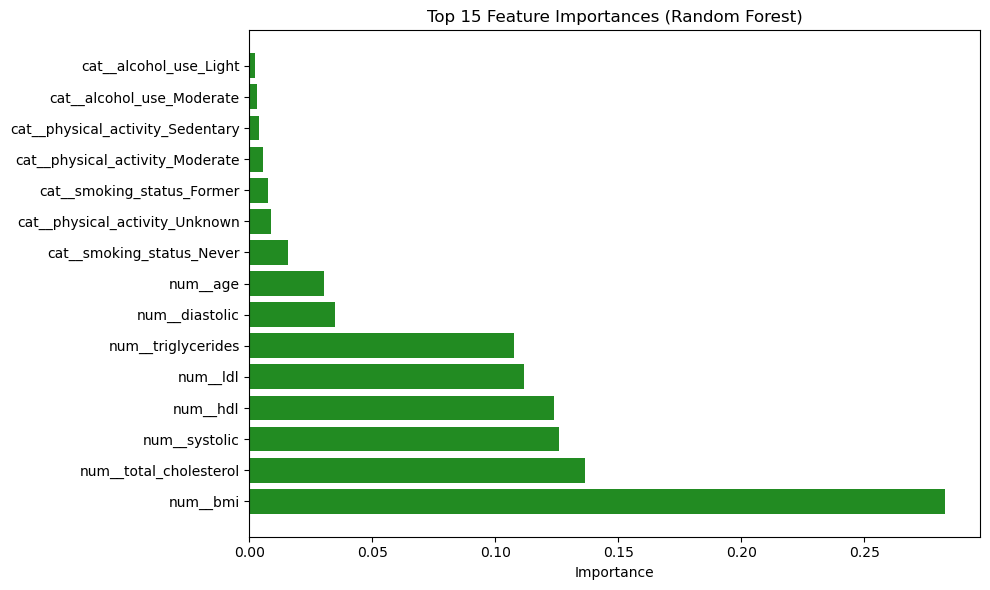

In [7]:
print("\n[2] Extracting feature importance")

numerical_features_list = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

importances = model.named_steps['classifier'].feature_importances_

try:
    feature_names_out = model.named_steps['preprocessor'].get_feature_names_out()
except:
    feature_names_out = numerical_features_list + [f"{cat}_encoded" for cat in categorical_features]

importance_df = pd.DataFrame({
    'Feature': feature_names_out,
    'Importance': importances
})
importance_df = importance_df.sort_values('Importance', ascending=False)

print("\n    Feature Importance Ranking:")
for idx, row in importance_df.head(15).iterrows():
    bar_length = int(row['Importance'] * 50)
    bar = '=' * bar_length
    print(f"    {row['Feature']:30s}: {row['Importance']:.4f} |{bar}")

# Visualize top features
plt.figure(figsize=(10, 6))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='forestgreen')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

## Make Predictions and Evaluate

In [8]:
print("\n[3] Making predictions")
y_train_pred = model.predict(X_train)
y_train_pred_proba = model.predict_proba(X_train)[:, 1]

y_test_pred = model.predict(X_test)
y_test_pred_proba = model.predict_proba(X_test)[:, 1]
print("    Predictions complete!")

train_metrics = print_evaluation_metrics_fixed(
    y_train, y_train_pred, y_train_pred_proba,
    "Random Forest - Training Set"
)

test_metrics = print_evaluation_metrics_fixed(
    y_test, y_test_pred, y_test_pred_proba,
    "Random Forest - Test Set"
)


[3] Making predictions
    Predictions complete!

EVALUATION RESULTS - Random Forest - Training Set

[PERFORMANCE METRICS]
  Accuracy:  0.7882 (78.82%)
  Precision: 0.4013 (40.13%)
  Recall:    0.8472 (84.72%)
  F1-Score:  0.5446
  ROC-AUC:   0.8933

[CONFUSION MATRIX]
                Predicted
              Neg    Pos
  Actual Neg   637    182
         Pos    22    122

[ADDITIONAL METRICS]
  True Positives:  122
  True Negatives:  637
  False Positives: 182
  False Negatives: 22
  Specificity:     0.7778
  NPV:             0.9666

[CLASSIFICATION REPORT]
              precision    recall  f1-score   support

Non-Diabetic       0.97      0.78      0.86       819
    Diabetic       0.40      0.85      0.54       144

    accuracy                           0.79       963
   macro avg       0.68      0.81      0.70       963
weighted avg       0.88      0.79      0.81       963


EVALUATION RESULTS - Random Forest - Test Set

[PERFORMANCE METRICS]
  Accuracy:  0.7651 (76.51%)
  Precisio

## Cross-Validation vs Test Set Comparison

In [9]:
print("\n" + "="*80)
print("CROSS-VALIDATION vs TEST SET COMPARISON")
print("="*80)
print(f"\n{'Metric':<12} {'CV Mean':<12} {'CV Std':<12} {'Test Set':<12} {'Match?':<12}")
print("-"*80)

metric_mapping = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1_score',
    'roc_auc': 'roc_auc'
}

for cv_metric, test_metric in metric_mapping.items():
    cv_mean = cv_results[cv_metric]['mean']
    cv_std = cv_results[cv_metric]['std']
    test_val = test_metrics[test_metric]
    match = "Good" if abs(cv_mean - test_val) < 2*cv_std else "Check"
    
    print(f"{cv_metric:<12} {cv_mean:>11.4f} {cv_std:>11.4f} {test_val:>11.4f} {match:<12}")

print("\n[OVERFITTING CHECK]")
accuracy_gap = train_metrics['accuracy'] - test_metrics['accuracy']
print(f"  Training accuracy: {train_metrics['accuracy']:.4f}")
print(f"  Test accuracy:     {test_metrics['accuracy']:.4f}")
print(f"  Gap:               {accuracy_gap:.4f}")

if accuracy_gap < 0.05:
    print("  Status: Good - No significant overfitting")
elif accuracy_gap < 0.10:
    print("  Status: Moderate - Some overfitting present")
else:
    print("  Status: High - Significant overfitting detected")

print("\n" + "="*80)
print("MODEL TRAINING COMPLETE!")
print("="*80)


CROSS-VALIDATION vs TEST SET COMPARISON

Metric       CV Mean      CV Std       Test Set     Match?      
--------------------------------------------------------------------------------
accuracy          0.7456      0.0335      0.7651 Good        
precision         0.3217      0.0363      0.3504 Good        
recall            0.6111      0.0457      0.6613 Good        
f1                0.4198      0.0336      0.4581 Good        
roc_auc           0.7646      0.0351      0.7975 Good        

[OVERFITTING CHECK]
  Training accuracy: 0.7882
  Test accuracy:     0.7651
  Gap:               0.0230
  Status: Good - No significant overfitting

MODEL TRAINING COMPLETE!
